# Supermarket Sales Analysis — Trends & KPIs


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r'..\dataset\supermarket_data.csv')
print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")


Rows: 3248  |  Columns: 18


In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
2,9,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040
3,11,CA-2015-115812,09/06/2015,14/06/2015,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032.0,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840
4,13,CA-2018-114412,15/04/2018,20/04/2018,Standard Class,AA-10480,Andrew Allen,Consumer,United States,Concord,North Carolina,28027.0,South,OFF-PA-10002365,Office Supplies,Paper,Xerox 1967,15.5520


In [5]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
3243,9794,CA-2015-127166,21/05/2015,23/05/2015,Second Class,KH-16360,Katherine Hughes,Consumer,United States,Houston,Texas,77070.0,Central,OFF-PA-10001560,Office Supplies,Paper,"Adams Telephone Message Books, 5 1/4” x 11”",4.832
3244,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
3245,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
3246,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
3247,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3248 entries, 0 to 3247
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         3248 non-null   int64  
 1   Order ID       3248 non-null   str    
 2   Order Date     3248 non-null   str    
 3   Ship Date      3248 non-null   str    
 4   Ship Mode      3248 non-null   str    
 5   Customer ID    3248 non-null   str    
 6   Customer Name  3248 non-null   str    
 7   Segment        3248 non-null   str    
 8   Country        3248 non-null   str    
 9   City           3248 non-null   str    
 10  State          3248 non-null   str    
 11  Postal Code    3242 non-null   float64
 12  Region         3248 non-null   str    
 13  Product ID     3248 non-null   str    
 14  Category       3248 non-null   str    
 15  Sub-Category   3248 non-null   str    
 16  Product Name   3248 non-null   str    
 17  Sales          3248 non-null   float64
dtypes: float64(2), int6

In [7]:
df.describe()

,Row ID,Postal Code,Sales
count,3248.000000,3242.000000,3248.000000
mean,4881.444273,56045.975632,262.184480
std,2859.594980,31612.930319,755.692055
min,1.000000,1453.000000,0.836000
25%,2413.750000,27707.000000,17.240000
50%,4829.500000,60094.000000,58.440000
75%,7377.250000,90008.000000,224.240000
max,9800.000000,99301.000000,22638.480000


## 1. Data Cleaning & Preparation

In [8]:
# Date (str to datetime conversion)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

# Feature engineering for trend analysis
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)
df['Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)

print("Missing values per column:")
print(df.isnull().sum())
print("---")
print(f"Duplicate rows: {df.duplicated().sum()}")
print("---")
print(f"Date range: {df['Order Date'].min().date()}  to  {df['Order Date'].max().date()}")


Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      6
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Year             0
Month            0
YearMonth        0
Quarter          0
dtype: int64
---
Duplicate rows: 0
---
Date range: 2015-01-04  to  2018-12-30


In [ ]:
# Year, Month, YearMonth, Quarter col are added
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,YearMonth,Quarter
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,2017-11,2017Q4
1,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,2016-10,2016Q4
2,9,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,2015,6,2015-06,2015Q2
3,11,CA-2015-115812,2015-06-09,2015-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,2015,6,2015-06,2015Q2
4,13,CA-2018-114412,2018-04-15,2018-04-20,Standard Class,AA-10480,Andrew Allen,Consumer,United States,Concord,...,South,OFF-PA-10002365,Office Supplies,Paper,Xerox 1967,15.5520,2018,4,2018-04,2018Q2


## 2. Key Performance Indicators (KPIs)

In [10]:
total_sales = df['Sales'].sum()
total_orders = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
total_line_items = len(df)
avg_order_value = df.groupby('Order ID')['Sales'].sum().mean()
avg_sale_per_line = df['Sales'].mean()

kpis = pd.DataFrame({
    'Metric': ['Total Sales', 'Total Orders', 'Unique Customers', 'Line Items',
               'Avg Order Value', 'Avg Sale per Line Item'],
    'Value': [f"${total_sales:,.2f}", f"{total_orders:,}", f"{total_customers:,}",
              f"{total_line_items:,}", f"${avg_order_value:,.2f}", f"${avg_sale_per_line:,.2f}"]
})
kpis


,Metric,Value
0,Total Sales,"$851,575.19"
1,Total Orders,"2,442"
2,Unique Customers,750
3,Line Items,"3,248"
4,Avg Order Value,$348.72
5,Avg Sale per Line Item,$262.18


## 3. Sales Trend Over Time (Monthly)

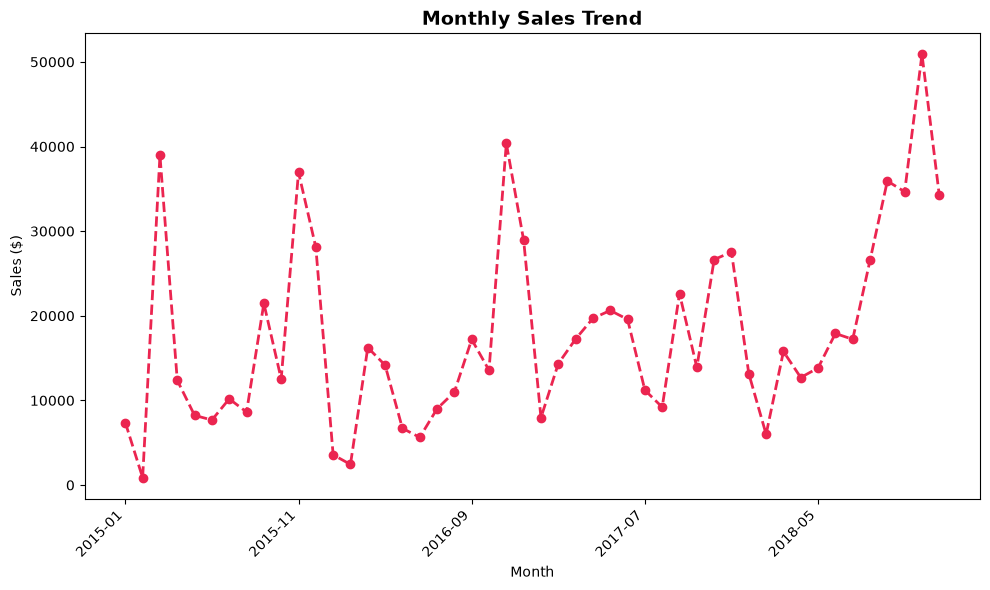

In [30]:
monthly_sales = df.groupby('YearMonth')['Sales'].sum().sort_index()

plt.figure(figsize=(10, 6))
monthly_sales.plot(linestyle='--', marker='o', color="#eb2550", linewidth=2)
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 4. Sales by Category & Sub-Category

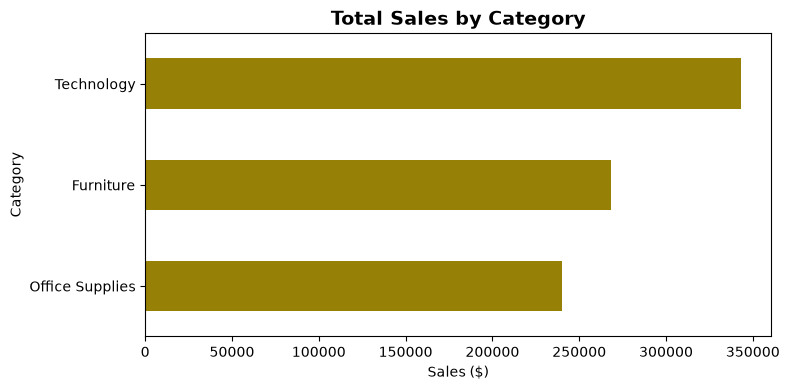

In [32]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
cat_sales.plot(kind='barh', color="#968005")
plt.title('Total Sales by Category', fontsize=14, fontweight='bold')
plt.xlabel('Sales ($)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


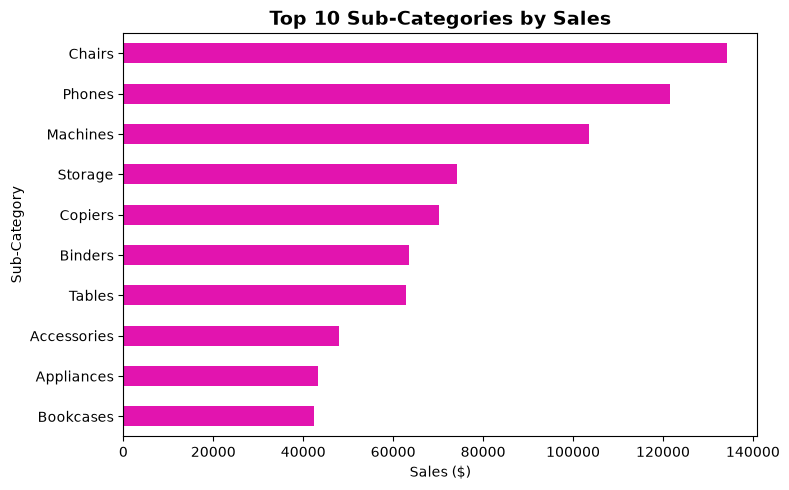

In [33]:
subcat_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
subcat_sales.plot(kind='barh', color="#e214af")
plt.title('Top 10 Sub-Categories by Sales', fontsize=14, fontweight='bold')
plt.xlabel('Sales ($)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 5. Sales by Region & Customer Segment

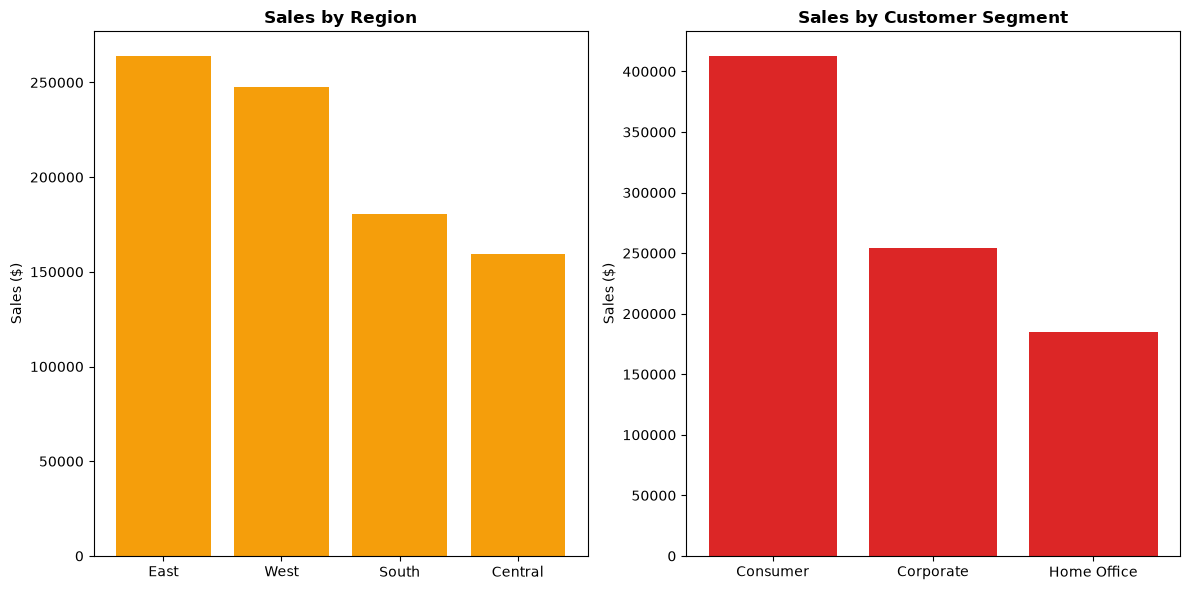

In [43]:
import matplotlib.pyplot as plt

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(region_sales.index, region_sales.values, color='#f59e0b')
plt.title('Sales by Region', fontweight='bold')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
plt.bar(segment_sales.index, segment_sales.values, color='#dc2626')
plt.title('Sales by Customer Segment', fontweight='bold')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 6. Top Products & Top Customers

In [15]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products.to_frame('Total Sales')


,Total Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,30099.914
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
Hewlett Packard LaserJet 3310 Copier,14999.750
"3D Systems Cube Printer, 2nd Generation, Magenta",14299.890
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",8749.950
Samsung Galaxy Mega 6.3,8315.802
DMI Eclipse Executive Suite Bookcases,8241.121
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,8134.336


In [51]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_customers.to_frame('Total Sales')


,Total Sales
Customer Name,
Sean Miller,23407.416
Hunter Lopez,12047.420
Tom Ashbrook,11323.898
Bill Shonely,9993.933
Sanjit Engle,9524.070
Todd Sumrall,8845.103
Christopher Conant,8759.058
Christopher Martinez,8395.206
Grant Thornton,7999.980


## 7. Sales by Ship Mode

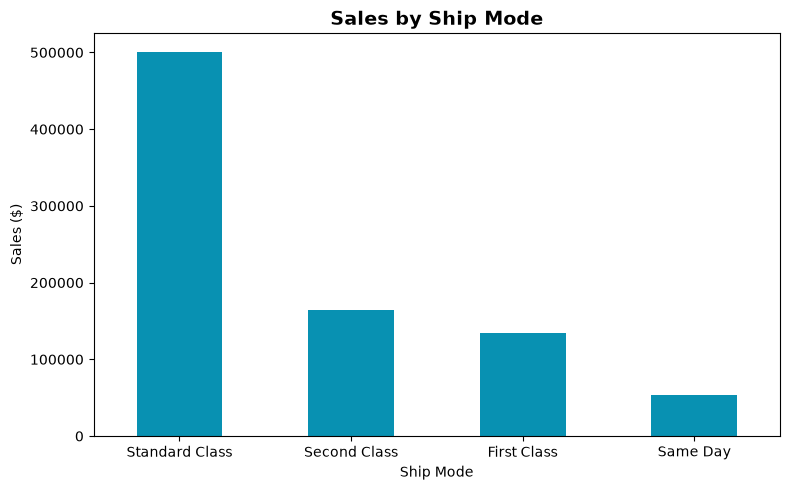

In [34]:
ship_sales = df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
ship_sales.plot(kind='bar', color='#0891b2')
plt.title('Sales by Ship Mode', fontsize=14, fontweight='bold')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
